# Task 1: Dataset Understanding

## Import Libraries and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/customer_support_text_classification.csv')

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


## Number of Records

In [2]:
print("Number of Records:", len(df))

Number of Records: 1500


## Target Labels / Classes

In [3]:
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


## Sample Text Records

In [4]:
print(df[['customer_message', 'sentiment_label']].head())

                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neutral


## Average Text Length

In [5]:
average_length = df['word_count'].mean()

print("Average Text Length:", average_length)

Average Text Length: 12.722666666666667


## Class Distribution

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


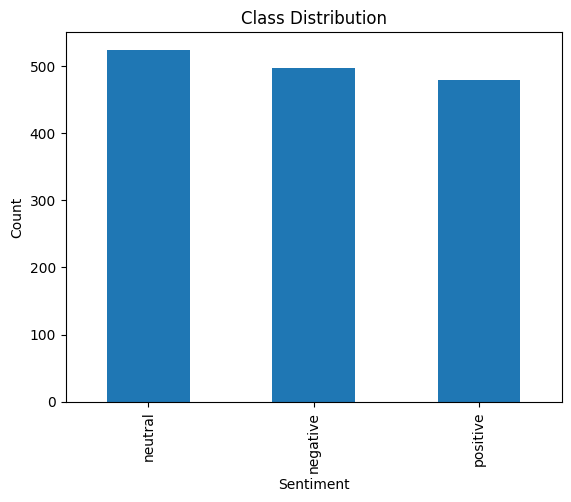

In [6]:
print(df['sentiment_label'].value_counts())

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Task 2: Text Preprocessing

## Import Required Libraries

In [7]:
import re
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Convert Text to Lowercase

In [8]:
df['clean_text'] = df['customer_message'].str.lower()

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process. ...
1,I need information about the payment process.,i need information about the payment process.
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient. i ...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details.


## Remove Special Characters

In [9]:
df['clean_text'] = df['clean_text'].apply(
lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details


## Tokenization

In [10]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

print(sequences[:5])

[[4, 29, 136, 39, 1, 90, 33, 3, 6, 7, 2, 10, 12, 8, 13, 8, 14], [4, 29, 136, 39, 1, 90, 33], [1, 28, 33, 11, 57, 5, 58, 4, 30, 1, 31, 22], [3, 28, 2, 120, 121, 5, 20, 52, 2, 122, 3, 6, 7, 2], [10, 63, 64, 65, 9, 48, 3, 45, 66]]


## Padding Sequences

In [11]:
padded_sequences = pad_sequences(
sequences,
maxlen=10,
padding='post'
)

print(padded_sequences[:5])

[[  3   6   7   2  10  12   8  13   8  14]
 [  4  29 136  39   1  90  33   0   0   0]
 [ 33  11  57   5  58   4  30   1  31  22]
 [121   5  20  52   2 122   3   6   7   2]
 [ 10  63  64  65   9  48   3  45  66   0]]


## Final Preprocessed Output

In [12]:
print(df['clean_text'].head())

0    i need information about the payment process m...
1         i need information about the payment process
2    the refund process was fast and convenient i a...
3    my refund is still pending and this experience...
4      please tell me how to update my account details
Name: clean_text, dtype: object


# Task 3: Text Vectorization

## Why Text Must Be Converted Into Vectors

Machine learning models cannot understand raw text directly.
Text must be converted into numerical vectors so the model can process patterns, relationships, and word importance mathematically.

TF-IDF helps convert text into numerical values based on how important a word is in a sentence and across the dataset.

## Import TF-IDF Vectorizer

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

## Apply TF-IDF Vectorization

In [14]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['clean_text'])

print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16784 stored elements and shape (1500, 180)>
  Coords	Values
  (0, 85)	0.2874818972700327
  (0, 63)	0.3585610063741839
  (0, 0)	0.2959850511828109
  (0, 146)	0.10038085754768535
  (0, 96)	0.3408974467955237
  (0, 106)	0.2889615259806446
  (0, 84)	0.13006585611047797
  (0, 150)	0.16216159471442107
  (0, 90)	0.16777355419932632
  (0, 68)	0.12877223611231733
  (0, 101)	0.20174922640270543
  (0, 124)	0.2276426865799241
  (0, 12)	0.4552853731598482
  (0, 135)	0.2276426865799241
  (0, 104)	0.2276426865799241
  (1, 85)	0.40310680665259346
  (1, 63)	0.5027738568660972
  (1, 0)	0.4150299199087853
  (1, 146)	0.14075393031474312
  (1, 96)	0.4780060326535575
  (1, 106)	0.4051815404366341
  (2, 146)	0.23732286794361881
  (2, 106)	0.34158493833604625
  (2, 118)	0.33811885926504115
  (2, 167)	0.2341905279676274
  :	:
  (1497, 85)	0.34282558304267
  (1497, 146)	0.11970536698797443
  (1497, 84)	0.1551050809753603
  (1497, 57)	0.3907549145090

## Shape of TF-IDF Matrix

In [15]:
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (1500, 180)


## Sample Feature Names

In [16]:
print(tfidf.get_feature_names_out()[:20])

['about' 'account' 'activate' 'after' 'ago' 'am' 'analytics' 'and' 'any'
 'app' 'appreciate' 'arrived' 'as' 'assigned' 'available' 'bad' 'because'
 'been' 'between' 'billing']


# Task 4: Baseline Model

## Import Required Libraries

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


## Define Features and Labels

In [18]:
X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment_label']

## Split Dataset into Training and Testing Sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

## Train Logistic Regression Model

In [20]:

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Make Predictions

In [21]:
y_pred = model.predict(X_test)

## Evaluate Model Performance

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



# Task 5: Sequence Model using LSTM


## Import Required Libraries

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import LabelEncoder

## Encode Target Labels

In [24]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment_label'])

## Build LSTM Model

In [25]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=10))

model.add(LSTM(64))

model.add(Dense(3, activation='softmax'))

model.compile(
loss='sparse_categorical_crossentropy',
optimizer='adam',
metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Architecture Explanation


- Input Sequence:
The tokenized and padded text sequences are used as input.

- Embedding Layer:
Converts words into dense numerical vectors so the model can understand semantic relationships between words.

- LSTM Layer:
Processes text sequentially and remembers important information from previous words in the sentence.

- Output Layer:
Uses Softmax activation to classify the sentiment into positive, neutral, or negative.

- Loss Function:
Sparse categorical crossentropy is used for multi-class classification.

- Evaluation Metric:
Accuracy is used to measure model performance.

# Task 6: Attention and Transformer Reflection

## Why RNNs struggle with long-term dependencies
RNNs process text one word at a time, but they often forget older information when sequences become very long. This problem is called the vanishing gradient problem.

## How LSTMs help with memory
LSTMs improve RNNs by using memory cells and gates that help retain important information for longer periods. This allows the model to better understand long sentences and context.

## What attention solves in sequence-to-sequence tasks
Attention helps the model focus on the most relevant words in a sentence instead of relying only on the last hidden state. This improves performance in tasks like translation and text summarization.

## Why transformers are important in modern NLP and Generative AI
Transformers process all words in parallel and use attention mechanisms to understand relationships between words efficiently. They are faster and more powerful than traditional RNNs and are used in modern AI models like ChatGPT, BERT, and Gemini.